# State-dependent effective liquidity

This notebook estimates a reduced-form liquidity mechanism motivated by the
regime-response results.  It asks whether the central logarithmic response is
stable across market activity, and whether effective liquidity falls relative
to that benchmark when **both** activity and imbalance are unusually high.

The analysis is deliberately not a structural model of separate limit-order
arrivals and cancellations.  Transaction data identify only their net effect,
together with other channels such as repricing, adverse selection and changes
in market-order composition.

The four nested specifications are:

1. a pooled logarithmic response;
2. a logarithmic response whose central parameters vary smoothly with activity;
3. the state-dependent log model with an activity/imbalance tail-liquidity term;
4. a secondary joint model that asks whether relative flow adds information.

The 4,000-event construction is primary. Five-minute bars provide a separate
clock-time robustness exercise. Fits use activity quintiles and 20 equal-count
imbalance bins within each quintile, retaining every state’s full observed
imbalance support.


## Theoretical mechanism

Let $u=x/x_{med}\geq0$ be absolute normalized imbalance and let
$z=\log(\lambda/\lambda_{med})$ be log event-arrival intensity relative to
its construction-specific median. Define the conditional response and
effective liquidity by

$$
R(u,z)=\mathbb{E}[\operatorname{sign}(Q_t)r_t\mid u_t=u,z_t=z],
\qquad
\mathcal L(u,z)=\left(\frac{\partial R(u,z)}{\partial u}\right)^{-1}.
$$

The state-dependent central logarithmic model is

$$
R_0(u,z)=A(z)\log\!\left(1+\frac{u}{u_0(z)}\right),\qquad
A(z)=e^{a_0+a_1z},\quad u_0(z)=e^{b_0+b_1z},
$$

so its implied effective liquidity is

$$
\mathcal L_0(u,z)=\frac{u_0(z)+u}{A(z)}.
$$

The tail extension allows liquidity to fall relative to this central schedule:

$$
\mathcal L(u,z)=\mathcal L_0(u,z)
\exp\{-\gamma_z(z-z_*)_+h(u;u_*)\},
\quad
h(u;u_*)=\log\!\left[1+\frac{(u-u_*)_+}{u_*}\right].
$$

The response is the integral of inverse effective liquidity. The model nests
the state-dependent logarithm at $\gamma_z=0$. The joint extension adds
$\gamma_f(f-f_*)_+$ to the tail exponent, where
$f$ is log relative flow centred on its median. Because relative flow and
normalized imbalance share volume terms, that extension is interpreted only
as an incremental predictive test.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from numpy.polynomial.legendre import leggauss
import pandas as pd
from scipy.optimize import least_squares

%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
default_project = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
PROJECT_DIR = Path(os.environ.get('CRYPTO_IMPACT_PROJECT_DIR', default_project)).resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.crypto_impact.impact import add_trailing_impact_normalisation
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars,
    load_monthly_trades,
    make_time_bars,
)
from src.crypto_impact.regime_analysis import build_analysis_table

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


In [13]:
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'BTCUSDT_monthly'
FIGURE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_FIGURE_DIR', PROJECT_DIR / 'reports' / 'figures')
)
TABLE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_TABLE_DIR', PROJECT_DIR / 'reports' / 'tables')
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_PER_BAR = 4_000
TIME_WINDOW = '5min'
TRAILING_WINDOW = '1D'
MIN_TRAILING_BARS = 100
N_ACTIVITY_BINS = 5
N_IMBALANCE_BINS = 20
MIN_OBS_PER_CELL = int(os.environ.get('CRYPTO_IMPACT_MIN_OBS_PER_CELL', '50'))
N_QUADRATURE_NODES = 32
N_STARTS = int(os.environ.get('CRYPTO_IMPACT_N_STARTS', '16'))
N_BOOTSTRAP = int(os.environ.get('CRYPTO_IMPACT_N_BOOTSTRAP', '100'))
N_CV_FOLDS = int(os.environ.get('CRYPTO_IMPACT_N_CV_FOLDS', '5'))
MAX_FILES_ENV = int(os.environ.get('CRYPTO_IMPACT_MAX_FILES', '0'))
MAX_FILES = MAX_FILES_ENV or None

files = sorted(DATA_DIR.glob('BTCUSDT-trades-*.parquet'))
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No monthly parquet files found in {DATA_DIR}')
print(f'Files selected: {len(files)} ({files[0].name} to {files[-1].name})')


Files selected: 17 (BTCUSDT-trades-2025-01.parquet to BTCUSDT-trades-2026-05.parquet)


## Construct the two analysis samples

Event intensity is $N_t/T_t$: it equals $4,000/T_t$ in event bars and
$N_t/300$ in five-minute bars. Centering by the sample median changes only
the origin of the state variable; it does not change its ordering. The
response and imbalance normalizations are identical to the pooled and regime
notebooks and exclude the current bar from their trailing benchmarks.


In [14]:
def prepare_normalised_analysis(bars):
    analysis = build_analysis_table(bars, horizons=())
    analysis = add_trailing_impact_normalisation(
        analysis,
        window=TRAILING_WINDOW,
        min_periods=MIN_TRAILING_BARS,
        timestamp_col='end_time',
    ).replace([np.inf, -np.inf], np.nan)
    analysis['block_day'] = pd.to_datetime(
        analysis['end_time'], utc=True
    ).dt.floor('D')
    analysis['event_intensity'] = (
        analysis['trade_count'] / analysis['duration_seconds']
    )
    return analysis


def add_model_scales(data):
    result = data.copy()
    valid = result[[
        'normalised_imbalance', 'normalised_signed_impact',
        'event_intensity', 'flow_rate_ratio',
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    valid = valid.loc[
        (valid['normalised_imbalance'] > 0)
        & (valid['event_intensity'] > 0)
        & (valid['flow_rate_ratio'] > 0)
    ]
    x_med = float(valid['normalised_imbalance'].median())
    intensity_med = float(valid['event_intensity'].median())
    relative_flow_med = float(valid['flow_rate_ratio'].median())
    result['imbalance_u'] = result['normalised_imbalance'] / x_med
    result['activity_z'] = np.log(result['event_intensity'] / intensity_med)
    result['relative_flow_f'] = np.log(
        result['flow_rate_ratio'] / relative_flow_med
    )
    result = result.replace([np.inf, -np.inf], np.nan).dropna(subset=[
        'imbalance_u', 'normalised_signed_impact', 'activity_z',
        'relative_flow_f', 'block_day',
    ])
    result = result.loc[result['imbalance_u'] > 0].copy()
    scales = {
        'x_med': x_med,
        'event_intensity_median': intensity_med,
        'relative_flow_ratio_median': relative_flow_med,
    }
    return result, scales


event_bars = build_fixed_event_bars(files, events_per_bar=EVENTS_PER_BAR)
event_analysis, event_scales = add_model_scales(
    prepare_normalised_analysis(event_bars)
)

time_frames = []
for path in files:
    monthly = make_time_bars(load_monthly_trades(path), window=TIME_WINDOW)
    monthly['start_time'] = monthly.index
    monthly['end_time'] = monthly.index + pd.Timedelta(TIME_WINDOW)
    monthly['duration_seconds'] = pd.Timedelta(TIME_WINDOW).total_seconds()
    monthly['source_file'] = path.name
    time_frames.append(monthly)
time_bars = pd.concat(time_frames).sort_index()
if not time_bars.index.is_unique:
    raise ValueError('Five-minute bar start times are not unique.')
time_analysis, time_scales = add_model_scales(
    prepare_normalised_analysis(time_bars)
)

analysis_samples = {
    'event_bars': event_analysis,
    'time_bars': time_analysis,
}
normalisation_table = pd.DataFrame({
    'event_bars': event_scales,
    'time_bars': time_scales,
}).T
normalisation_table.index.name = 'construction'
normalisation_table


,x_med,event_intensity_median,relative_flow_ratio_median
construction,,,
event_bars,0.000540,13.085601,1.066563
time_bars,0.000358,7.186667,0.627345


## Build the conditional response surfaces

Activity quintiles are used only to construct well-populated conditional
means. Within every activity quintile, imbalance is independently divided
into 20 equal-count bins. This preserves the complete imbalance support of
every activity state. The nonlinear models use the mean continuous values
(u,z,f) in each cell rather than treating the quintile labels as parameters.


In [20]:
def build_response_surface(data):
    columns = [
        'imbalance_u', 'activity_z', 'relative_flow_f',
        'normalised_signed_impact', 'block_day',
    ]
    sample = data.loc[:, columns].replace([np.inf, -np.inf], np.nan).dropna()
    sample = sample.loc[sample['imbalance_u'] > 0].copy()
    sample['activity_bin'] = pd.qcut(
        sample['activity_z'], q=N_ACTIVITY_BINS,
        labels=False, duplicates='drop',
    )
    if sample['activity_bin'].nunique() != N_ACTIVITY_BINS:
        raise ValueError('Insufficient distinct activity values for five quintiles.')

    frames = []
    assigned = []
    for activity_bin, group in sample.groupby('activity_bin', observed=True):
        group = group.copy()
        group['imbalance_bin'] = pd.qcut(
            group['imbalance_u'], q=N_IMBALANCE_BINS,
            labels=False, duplicates='drop',
        )
        if group['imbalance_bin'].nunique() != N_IMBALANCE_BINS:
            raise ValueError(
                f'Insufficient distinct imbalance values in activity bin {activity_bin}.'
            )
        assigned.append(group)
        cell = (
            group.groupby('imbalance_bin', observed=True)
            .agg(
                mean_u=('imbalance_u', 'mean'),
                median_u=('imbalance_u', 'median'),
                mean_z=('activity_z', 'mean'),
                median_z=('activity_z', 'median'),
                mean_f=('relative_flow_f', 'mean'),
                median_f=('relative_flow_f', 'median'),
                mean_impact=('normalised_signed_impact', 'mean'),
                median_impact=('normalised_signed_impact', 'median'),
                impact_std=('normalised_signed_impact', 'std'),
                n_obs=('normalised_signed_impact', 'count'),
                n_days=('block_day', 'nunique'),
            )
            .reset_index()
        )
        cell.insert(0, 'activity_bin', int(activity_bin))
        frames.append(cell)
    surface = pd.concat(frames, ignore_index=True)
    surface['standard_error'] = surface['impact_std'] / np.sqrt(surface['n_obs'])
    surface = surface.loc[
        (surface['n_obs'] >= MIN_OBS_PER_CELL)
        & np.isfinite(surface['standard_error'])
        & (surface['standard_error'] > 0)
    ].copy()
    surface['activity_bin'] = surface['activity_bin'].astype(int)
    surface['imbalance_bin'] = surface['imbalance_bin'].astype(int)
    assigned = pd.concat(assigned).sort_index()
    return surface.sort_values(['activity_bin', 'imbalance_bin']), assigned


surface_data = {}
assigned_data = {}
for construction, sample in analysis_samples.items():
    surface_data[construction], assigned_data[construction] = (
        build_response_surface(sample)
    )

pd.DataFrame({
    construction: {
        'observations': len(analysis_samples[construction]),
        'UTC days': analysis_samples[construction]['block_day'].nunique(),
        'surface cells': len(surface),
        'minimum observations per retained cell': surface['n_obs'].min(),
    }
    for construction, surface in surface_data.items()
}).T


,observations,UTC days,surface cells,minimum observations per retained cell
event_bars,111576,506,100,1115
time_bars,148505,517,100,1484


## Model functions and weighted nonlinear fitting

The tail response has no convenient elementary closed form. It is evaluated
with fixed Gauss--Legendre quadrature, which is deterministic and fast inside
nonlinear least squares. Thresholds and tail coefficients are constrained to
economically meaningful ranges. Multiple deterministic starts reduce the
chance of retaining a local optimum.


In [21]:
QUAD_NODES, QUAD_WEIGHTS = leggauss(N_QUADRATURE_NODES)
MODEL_ORDER = ['pooled_log', 'state_log', 'activity_tail', 'joint_tail']
PARAMETER_NAMES = {
    'pooled_log': ['log_A', 'log_u0'],
    'state_log': ['log_A', 'A_activity_slope', 'log_u0', 'u0_activity_slope'],
    'activity_tail': [
        'log_A', 'A_activity_slope', 'log_u0', 'u0_activity_slope',
        'gamma_activity', 'activity_threshold_z', 'log_imbalance_threshold_u',
    ],
    'joint_tail': [
        'log_A', 'A_activity_slope', 'log_u0', 'u0_activity_slope',
        'gamma_activity', 'activity_threshold_z', 'log_imbalance_threshold_u',
        'gamma_relative_flow', 'relative_flow_threshold_f',
    ],
}


def central_parameters(params, z):
    A = np.exp(params[0] + params[1] * z)
    u0 = np.exp(params[2] + params[3] * z)
    return A, u0


def tail_response(u, z, f, params, include_relative_flow=False):
    u = np.asarray(u, dtype=float)
    z = np.asarray(z, dtype=float)
    f = np.asarray(f, dtype=float)
    A, u0 = central_parameters(params, z)
    gamma_z, z_star, log_u_star = params[4:7]
    u_star = np.exp(log_u_star)
    kappa = gamma_z * np.maximum(z - z_star, 0.0)
    if include_relative_flow:
        gamma_f, f_star = params[7:9]
        kappa = kappa + gamma_f * np.maximum(f - f_star, 0.0)

    central_end = np.minimum(u, u_star)
    central_response = A * np.log1p(central_end / u0)
    tail_width = np.maximum(u - u_star, 0.0)
    nodes = u_star + 0.5 * tail_width[:, None] * (
        QUAD_NODES[None, :] + 1.0
    )
    h = np.log(nodes / u_star)
    exponent = np.clip(kappa[:, None] * h, 0.0, 30.0)
    integrand = A[:, None] * np.exp(exponent) / (u0[:, None] + nodes)
    tail_response_value = 0.5 * tail_width * np.sum(
        QUAD_WEIGHTS[None, :] * integrand, axis=1
    )
    no_tail_adjustment = kappa <= 1e-12
    exact_log_tail = A * (
        np.log1p(u / u0) - np.log1p(central_end / u0)
    )
    tail_response_value = np.where(
        no_tail_adjustment, exact_log_tail, tail_response_value
    )
    return central_response + tail_response_value


def predict_model(model, params, data):
    u = np.asarray(data['mean_u'], dtype=float)
    z = np.asarray(data['mean_z'], dtype=float)
    f = np.asarray(data['mean_f'], dtype=float)
    if model == 'pooled_log':
        A, u0 = np.exp(params)
        return A * np.log1p(u / u0)
    if model == 'state_log':
        A, u0 = central_parameters(params, z)
        return A * np.log1p(u / u0)
    if model == 'activity_tail':
        return tail_response(u, z, f, params, include_relative_flow=False)
    if model == 'joint_tail':
        return tail_response(u, z, f, params, include_relative_flow=True)
    raise ValueError(f'Unknown model: {model}')


def parameter_bounds(model, surface):
    z = surface['mean_z'].to_numpy()
    f = surface['mean_f'].to_numpy()
    u = surface['mean_u'].to_numpy()
    central_lower = [-12.0, -3.0, -7.0, -3.0]
    central_upper = [2.0, 3.0, 7.0, 3.0]
    if model == 'pooled_log':
        return np.array([-12.0, -7.0]), np.array([2.0, 7.0])
    if model == 'state_log':
        return np.array(central_lower), np.array(central_upper)
    tail_lower = [
        *central_lower, 0.0, np.quantile(z, 0.10),
        np.log(np.quantile(u, 0.40)),
    ]
    tail_upper = [
        *central_upper, 5.0, np.quantile(z, 0.95),
        np.log(np.quantile(u, 0.995)),
    ]
    if model == 'activity_tail':
        return np.array(tail_lower), np.array(tail_upper)
    return (
        np.array([*tail_lower, 0.0, np.quantile(f, 0.10)]),
        np.array([*tail_upper, 5.0, np.quantile(f, 0.95)]),
    )


def initial_parameters(model, surface, previous_fits):
    if model == 'pooled_log':
        positive = surface.loc[surface['mean_impact'] > 0, 'mean_impact']
        A0 = float(positive.median()) if len(positive) else 0.03
        return np.log([max(A0, 1e-4), 1.0])
    if model == 'state_log':
        pooled = previous_fits['pooled_log']['params']
        return np.array([pooled[0], 0.0, pooled[1], 0.0])
    if model == 'activity_tail':
        central = previous_fits['state_log']['params']
        return np.array([
            *central, 0.15,
            surface['mean_z'].quantile(0.80),
            np.log(surface['mean_u'].quantile(0.90)),
        ])
    activity = previous_fits['activity_tail']['params']
    return np.array([
        *activity, 0.05, surface['mean_f'].quantile(0.80),
    ])


def fit_one_model(model, surface, previous_fits, n_starts=N_STARTS, random_state=0):
    data = surface.replace([np.inf, -np.inf], np.nan).dropna(subset=[
        'mean_u', 'mean_z', 'mean_f', 'mean_impact', 'standard_error',
    ]).copy()
    lower, upper = parameter_bounds(model, data)
    initial = np.clip(
        initial_parameters(model, data, previous_fits),
        lower + 1e-8, upper - 1e-8,
    )
    sigma = data['standard_error'].to_numpy(dtype=float)
    fallback = np.median(sigma[np.isfinite(sigma) & (sigma > 0)])
    sigma = np.where(np.isfinite(sigma) & (sigma > 0), sigma, fallback)
    y = data['mean_impact'].to_numpy(dtype=float)

    def residuals(params):
        return (y - predict_model(model, params, data)) / sigma

    rng = np.random.default_rng(random_state)
    starts = [initial]
    for _ in range(max(1, n_starts) - 1):
        draw = initial + rng.normal(0.0, 0.20, size=len(initial)) * (upper - lower)
        draw = np.clip(draw, lower + 1e-7, upper - 1e-7)
        starts.append(draw)

    best = None
    for start in starts:
        result = least_squares(
            residuals, start, bounds=(lower, upper),
            max_nfev=25_000, xtol=1e-10, ftol=1e-10, gtol=1e-10,
        )
        if best is None or np.sum(result.fun**2) < np.sum(best.fun**2):
            best = result
    prediction = predict_model(model, best.x, data)
    return {
        'model': model,
        'params': best.x,
        'lower_bounds': lower,
        'upper_bounds': upper,
        'success': bool(best.success),
        'message': best.message,
        'cost': float(np.sum(best.fun**2)),
        'data': data,
        'prediction': prediction,
        'residual': y - prediction,
    }


def fit_model_sequence(surface, n_starts=N_STARTS, random_state=0):
    fits = {}
    for model_number, model in enumerate(MODEL_ORDER):
        fits[model] = fit_one_model(
            model, surface, fits, n_starts=n_starts,
            random_state=random_state + model_number,
        )
    return fits


In [22]:
model_fits = {
    construction: fit_model_sequence(
        surface, random_state=10_000 + construction_number * 100
    )
    for construction_number, (construction, surface) in enumerate(surface_data.items())
}


## Parameter estimates and in-sample fit

Weighted RMSE uses the same inverse-squared-standard-error weighting as the
earlier curve comparisons. `tail_wrmse` evaluates the highest imbalance bin
in every activity quintile; `high_activity_tail_wrmse` evaluates the single
highest-activity/highest-imbalance cell. The latter is informative but should
not be used alone for model selection.


In [23]:
def weighted_rmse(residual, standard_error):
    weights = 1.0 / np.asarray(standard_error, dtype=float)**2
    residual = np.asarray(residual, dtype=float)
    return float(np.sqrt(np.sum(weights * residual**2) / np.sum(weights)))


def fit_summary_row(fit):
    data = fit['data']
    residual = fit['residual']
    tail = data['imbalance_bin'] == data['imbalance_bin'].max()
    high_tail = tail & (data['activity_bin'] == data['activity_bin'].max())
    k = len(fit['params'])
    chi_square = fit['cost']
    bound_tolerance = 1e-4 * (
        fit['upper_bounds'] - fit['lower_bounds']
    )
    at_bound = (
        (fit['params'] - fit['lower_bounds'] <= bound_tolerance)
        | (fit['upper_bounds'] - fit['params'] <= bound_tolerance)
    )
    bound_names = np.asarray(PARAMETER_NAMES[fit['model']])[at_bound]
    return {
        'model': fit['model'],
        'parameters': k,
        'cells': len(data),
        'weighted_rmse': weighted_rmse(residual, data['standard_error']),
        'tail_wrmse': weighted_rmse(
            residual[tail], data.loc[tail, 'standard_error']
        ),
        'high_activity_tail_wrmse': weighted_rmse(
            residual[high_tail], data.loc[high_tail, 'standard_error']
        ),
        'unweighted_rmse': float(np.sqrt(np.mean(residual**2))),
        'weighted_chi_square': chi_square,
        'weighted_aic_up_to_constant': chi_square + 2 * k,
        'parameters_at_bound': int(at_bound.sum()),
        'bound_parameter_names': ';'.join(bound_names),
        'converged': fit['success'],
    }


def transformed_parameters(model, params):
    values = dict(zip(PARAMETER_NAMES[model], params))
    output = {
        'A_at_median_activity': np.exp(values['log_A']),
        'u0_at_median_activity': np.exp(values['log_u0']),
    }
    if model != 'pooled_log':
        output.update({
            'A_activity_slope': values['A_activity_slope'],
            'u0_activity_slope': values['u0_activity_slope'],
        })
    if model in {'activity_tail', 'joint_tail'}:
        output.update({
            'gamma_activity': values['gamma_activity'],
            'activity_threshold_z': values['activity_threshold_z'],
            'activity_threshold_multiple': np.exp(values['activity_threshold_z']),
            'imbalance_threshold_u': np.exp(values['log_imbalance_threshold_u']),
        })
    if model == 'joint_tail':
        output.update({
            'gamma_relative_flow': values['gamma_relative_flow'],
            'relative_flow_threshold_f': values['relative_flow_threshold_f'],
            'relative_flow_threshold_multiple': np.exp(
                values['relative_flow_threshold_f']
            ),
        })
    return output


fit_rows = []
parameter_rows = []
prediction_frames = []
for construction, fits in model_fits.items():
    for model, fit in fits.items():
        fit_rows.append({'construction': construction, **fit_summary_row(fit)})
        parameter_rows.append({
            'construction': construction, 'model': model,
            **transformed_parameters(model, fit['params']),
        })
        prediction = fit['data'].copy()
        prediction.insert(0, 'construction', construction)
        prediction['model'] = model
        prediction['predicted_impact'] = fit['prediction']
        prediction['residual'] = fit['residual']
        prediction_frames.append(prediction)

fit_statistics = pd.DataFrame(fit_rows)
parameter_estimates = pd.DataFrame(parameter_rows)
surface_predictions = pd.concat(prediction_frames, ignore_index=True)
fit_statistics


,construction,model,parameters,cells,weighted_rmse,tail_wrmse,high_activity_tail_wrmse,unweighted_rmse,weighted_chi_square,weighted_aic_up_to_constant,parameters_at_bound,bound_parameter_names,converged
0,event_bars,pooled_log,2,100,0.002635,0.005055,0.011425,0.002869,359.182914,363.182914,0,,True
1,event_bars,state_log,4,100,0.001733,0.004893,0.012622,0.002141,155.298251,163.298251,0,,True
2,event_bars,activity_tail,7,100,0.001395,0.002468,0.004011,0.001488,100.623191,114.623191,0,,True
3,event_bars,joint_tail,9,100,0.001357,0.001639,0.000229,0.001379,95.282997,113.282997,2,log_imbalance_threshold_u;relative_flow_thresh...,True
4,time_bars,pooled_log,2,100,0.003560,0.017967,0.073903,0.009326,"1,742.781360","1,746.781360",0,,True
5,time_bars,state_log,4,100,0.000953,0.002913,0.017521,0.002060,124.820393,132.820393,0,,True
6,time_bars,activity_tail,7,100,0.000827,0.000364,0.000042,0.000963,93.929735,107.929735,0,,True
7,time_bars,joint_tail,9,100,0.000826,0.000337,0.000016,0.000963,93.910712,111.910712,0,,True


In [19]:
parameter_estimates


,construction,model,A_at_median_activity,u0_at_median_activity,A_activity_slope,u0_activity_slope,gamma_activity,activity_threshold_z,activity_threshold_multiple,imbalance_threshold_u,gamma_relative_flow,relative_flow_threshold_f,relative_flow_threshold_multiple
0,event_bars,pooled_log,0.054417,1.214985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,event_bars,state_log,0.054155,1.206041,-0.098270,-0.256275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,event_bars,activity_tail,0.043000,0.865810,-0.309779,-0.586542,0.134367,-0.950877,0.386402,0.756641,NaN,NaN,NaN
3,event_bars,joint_tail,0.044804,0.915531,-0.316105,-0.598931,0.106051,-0.950877,0.386402,0.756394,0.067655,1.747067,5.737747
4,time_bars,pooled_log,0.056051,2.112850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,time_bars,state_log,0.037567,1.191099,0.554173,0.608014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,time_bars,activity_tail,0.036535,1.141457,0.414476,0.399383,0.211805,0.321825,1.379643,3.573489,NaN,NaN,NaN
7,time_bars,joint_tail,0.036487,1.139252,0.414486,0.399371,0.191642,0.402311,1.495276,3.477247,0.013659,-0.054528,0.946932


## Day-block bootstrap

Complete UTC days are resampled. Each draw reconstructs the conditional
surface and refits the state-log and activity-tail models. The reported
improvement is therefore conditional on the same binning and weighting
procedure as the main estimates. The bootstrap targets the activity-tail
coefficient and thresholds; it does not turn the reduced-form mechanism into
a causal or structural estimate.


In [9]:
def bootstrap_activity_tail(data, n_bootstrap=N_BOOTSTRAP, random_state=0):
    day_groups = {
        day: group for day, group in data.groupby('block_day', observed=True)
    }
    days = np.asarray(list(day_groups), dtype=object)
    if len(days) < 2:
        raise ValueError('At least two UTC days are required for the bootstrap.')
    rng = np.random.default_rng(random_state)
    rows = []
    for bootstrap_sample in range(n_bootstrap):
        sampled_days = rng.choice(days, size=len(days), replace=True)
        draw = pd.concat(
            [day_groups[day].assign(_bootstrap_day=draw_number)
             for draw_number, day in enumerate(sampled_days)],
            ignore_index=True,
        )
        try:
            surface, _ = build_response_surface(draw)
            fits = {}
            for model_number, model in enumerate(
                ['pooled_log', 'state_log', 'activity_tail']
            ):
                fits[model] = fit_one_model(
                    model, surface, fits,
                    n_starts=max(3, N_STARTS // 3),
                    random_state=(
                        random_state + bootstrap_sample * 10 + model_number
                    ),
                )
        except (RuntimeError, ValueError):
            continue
        central = fit_summary_row(fits['state_log'])
        tail = fit_summary_row(fits['activity_tail'])
        transformed = transformed_parameters(
            'activity_tail', fits['activity_tail']['params']
        )
        rows.append({
            'bootstrap_sample': bootstrap_sample,
            **transformed,
            'state_log_wrmse': central['weighted_rmse'],
            'activity_tail_wrmse': tail['weighted_rmse'],
            'wrmse_improvement_pct': 100 * (
                central['weighted_rmse'] - tail['weighted_rmse']
            ) / central['weighted_rmse'],
            'state_log_tail_wrmse': central['tail_wrmse'],
            'activity_tail_tail_wrmse': tail['tail_wrmse'],
            'tail_wrmse_improvement_pct': 100 * (
                central['tail_wrmse'] - tail['tail_wrmse']
            ) / central['tail_wrmse'],
        })
    return pd.DataFrame(rows)


bootstrap_frames = []
for construction_number, (construction, sample) in enumerate(analysis_samples.items()):
    draws = bootstrap_activity_tail(
        sample,
        n_bootstrap=N_BOOTSTRAP,
        random_state=20_000 + construction_number * 1_000,
    )
    draws.insert(0, 'construction', construction)
    bootstrap_frames.append(draws)
liquidity_bootstrap = pd.concat(bootstrap_frames, ignore_index=True)

bootstrap_summary = (
    liquidity_bootstrap.groupby('construction', observed=True)
    .agg(
        bootstrap_samples=('bootstrap_sample', 'count'),
        gamma_median=('gamma_activity', 'median'),
        gamma_p025=('gamma_activity', lambda x: x.quantile(0.025)),
        gamma_p975=('gamma_activity', lambda x: x.quantile(0.975)),
        activity_threshold_multiple_median=('activity_threshold_multiple', 'median'),
        activity_threshold_multiple_p025=(
            'activity_threshold_multiple', lambda x: x.quantile(0.025)
        ),
        activity_threshold_multiple_p975=(
            'activity_threshold_multiple', lambda x: x.quantile(0.975)
        ),
        imbalance_threshold_u_median=('imbalance_threshold_u', 'median'),
        imbalance_threshold_u_p025=(
            'imbalance_threshold_u', lambda x: x.quantile(0.025)
        ),
        imbalance_threshold_u_p975=(
            'imbalance_threshold_u', lambda x: x.quantile(0.975)
        ),
        tail_wrmse_improvement_median=('tail_wrmse_improvement_pct', 'median'),
        probability_positive_tail_improvement=(
            'tail_wrmse_improvement_pct', lambda x: (x > 0).mean()
        ),
    )
)
bootstrap_summary


,bootstrap_samples,gamma_median,gamma_p025,gamma_p975,activity_threshold_multiple_median,activity_threshold_multiple_p025,activity_threshold_multiple_p975,imbalance_threshold_u_median,imbalance_threshold_u_p025,imbalance_threshold_u_p975,tail_wrmse_improvement_median,probability_positive_tail_improvement
construction,,,,,,,,,,,,
event_bars,100,0.260867,0.126106,0.458139,0.684903,0.411309,1.203230,2.922456,0.712416,4.857753,61.682021,1.000000
time_bars,100,0.197859,0.107620,0.754491,1.449181,0.432919,3.217521,3.427557,0.978740,9.058962,63.592281,1.000000


## Blocked out-of-sample comparison

Consecutive UTC days are divided into time-ordered folds. For each fold, the
response surface and all models are estimated on the remaining days; a new
surface is constructed from the held-out days and scored without refitting.
This checks whether the additional tail parameters improve prediction rather
than only accommodating the in-sample final bins.


In [10]:
def blocked_cross_validation(data, n_folds=N_CV_FOLDS, random_state=0):
    days = np.asarray(sorted(data['block_day'].dropna().unique()))
    if len(days) < n_folds:
        raise ValueError('Fewer UTC days than requested cross-validation folds.')
    folds = np.array_split(days, n_folds)
    rows = []
    for fold_number, test_days in enumerate(folds):
        train = data.loc[~data['block_day'].isin(test_days)]
        test = data.loc[data['block_day'].isin(test_days)]
        train_surface, _ = build_response_surface(train)
        test_surface, _ = build_response_surface(test)
        fits = fit_model_sequence(
            train_surface,
            n_starts=max(4, N_STARTS // 2),
            random_state=random_state + fold_number * 100,
        )
        for model, fit in fits.items():
            prediction = predict_model(model, fit['params'], test_surface)
            residual = test_surface['mean_impact'].to_numpy() - prediction
            tail = (
                test_surface['imbalance_bin']
                == test_surface['imbalance_bin'].max()
            )
            rows.append({
                'fold': fold_number,
                'test_start': pd.Timestamp(test_days[0]),
                'test_end': pd.Timestamp(test_days[-1]),
                'model': model,
                'test_cells': len(test_surface),
                'test_weighted_rmse': weighted_rmse(
                    residual, test_surface['standard_error']
                ),
                'test_tail_weighted_rmse': weighted_rmse(
                    residual[tail], test_surface.loc[tail, 'standard_error']
                ),
            })
    return pd.DataFrame(rows)


cv_frames = []
for construction_number, (construction, sample) in enumerate(analysis_samples.items()):
    cv = blocked_cross_validation(
        sample,
        n_folds=N_CV_FOLDS,
        random_state=30_000 + construction_number * 1_000,
    )
    cv.insert(0, 'construction', construction)
    cv_frames.append(cv)
cross_validation = pd.concat(cv_frames, ignore_index=True)

cross_validation_summary = (
    cross_validation.groupby(['construction', 'model'], observed=True)
    .agg(
        folds=('fold', 'count'),
        mean_test_wrmse=('test_weighted_rmse', 'mean'),
        mean_test_tail_wrmse=('test_tail_weighted_rmse', 'mean'),
    )
    .reset_index()
)
cross_validation_summary


,construction,model,folds,mean_test_wrmse,mean_test_tail_wrmse
0,event_bars,activity_tail,5,0.001277,0.002926
1,event_bars,joint_tail,5,0.001260,0.002566
2,event_bars,pooled_log,5,0.001444,0.002800
3,event_bars,state_log,5,0.001351,0.003528
4,time_bars,activity_tail,5,0.002176,0.005149
5,time_bars,joint_tail,5,0.002176,0.005195
6,time_bars,pooled_log,5,0.004067,0.018854
7,time_bars,state_log,5,0.002251,0.006249


## Response and implied-liquidity figure

Points are the same conditional means used in estimation. In the response
panels, lines evaluate the fitted activity-tail model at each cell's own mean
imbalance and activity. They therefore show the fitted path through the
conditional surface rather than a counterfactual curve at one fixed state.

The effective-liquidity panels hold activity at each quintile's representative
value in order to isolate the model mechanism. A value below one is a fitted
shortfall relative to the corresponding state-dependent central logarithmic
schedule, not observed order-book depth.

The secondary diagnostic contrasts these two plotting conventions in the
fastest quintile. This matters when activity continues to change systematically
with imbalance even after conditioning on the broad quintile.


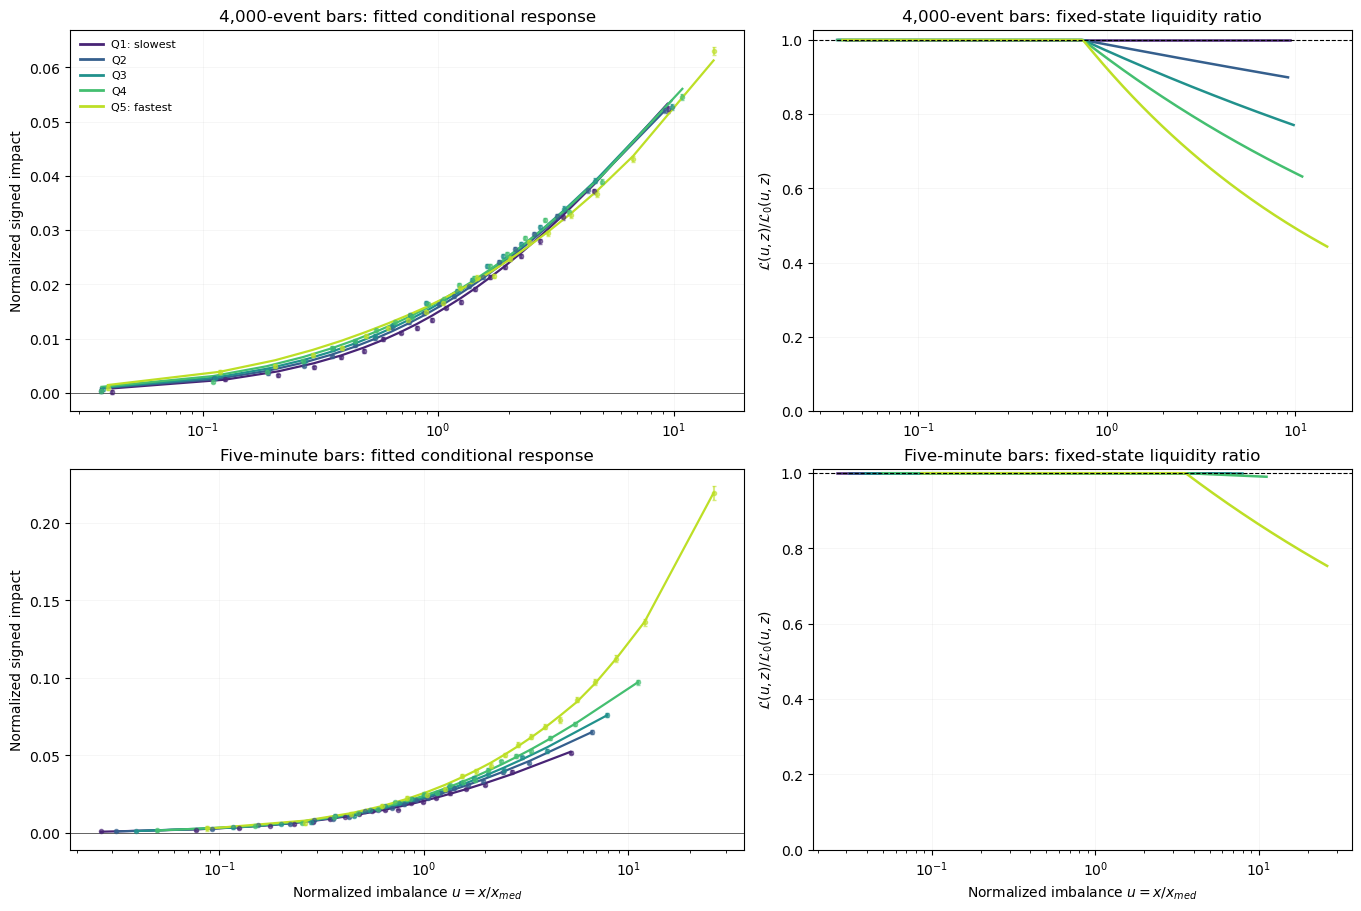

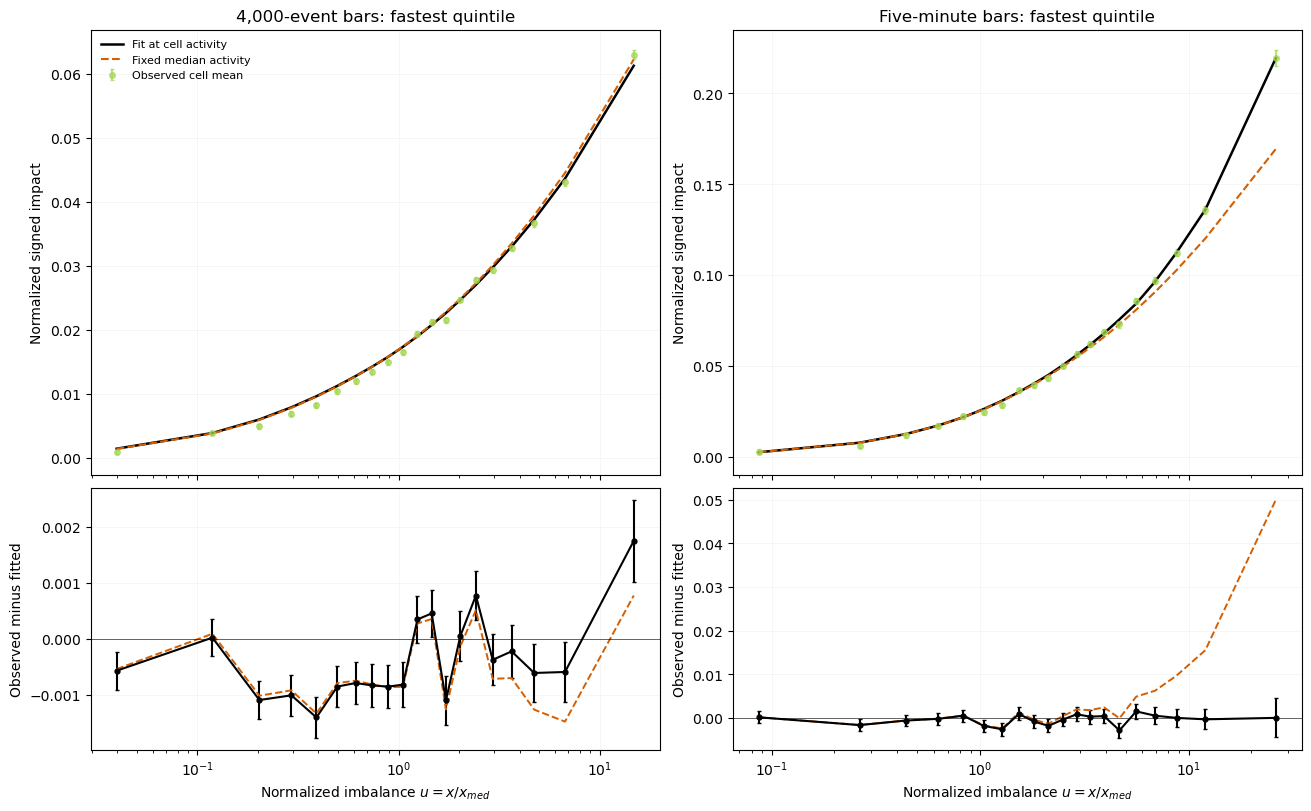

,construction,imbalance_bin,mean_u,mean_z,mean_impact,fitted_cell_prediction,cell_residual,fixed_state_prediction,fixed_state_residual
15,event_bars,15,2.939080,1.535499,0.029399,0.029774,-0.000375,0.030114,-0.000715
16,event_bars,16,3.650455,1.574904,0.032809,0.033034,-0.000225,0.033510,-0.000701
17,event_bars,17,4.728417,1.623081,0.036649,0.037260,-0.000610,0.037914,-0.001264
18,event_bars,18,6.726209,1.688323,0.043073,0.043666,-0.000592,0.044551,-0.001478
19,event_bars,19,14.774094,1.820265,0.063042,0.061297,0.001745,0.062271,0.000771
35,time_bars,15,5.608702,1.182363,0.085977,0.084453,0.001523,0.081070,0.004906
36,time_bars,16,6.910705,1.247146,0.097114,0.096573,0.000540,0.090851,0.006262
37,time_bars,17,8.757111,1.324335,0.112533,0.112497,0.000035,0.102814,0.009718
38,time_bars,18,12.043410,1.381341,0.135864,0.136159,-0.000295,0.120318,0.015546
39,time_bars,19,26.222346,1.573958,0.219415,0.219374,0.000042,0.169435,0.049981


In [11]:
def make_prediction_frame(u, z, f):
    return pd.DataFrame({'mean_u': u, 'mean_z': z, 'mean_f': f})


fig, axes = plt.subplots(
    2, 2, figsize=(13.5, 9.0), constrained_layout=True,
    gridspec_kw={'width_ratios': [1.25, 1.0]},
)
colours = plt.cm.viridis(np.linspace(0.10, 0.90, N_ACTIVITY_BINS))

for row, construction in enumerate(['event_bars', 'time_bars']):
    surface = surface_data[construction]
    fit = model_fits[construction]['activity_tail']
    params = fit['params']
    response_ax, liquidity_ax = axes[row]
    for activity_bin, colour in zip(range(N_ACTIVITY_BINS), colours):
        state = surface.loc[
            surface['activity_bin'] == activity_bin
        ].sort_values('mean_u')
        if state.empty:
            continue
        response_ax.errorbar(
            state['mean_u'], state['mean_impact'], yerr=state['standard_error'],
            fmt='o', ms=3.0, capsize=1.2, color=colour, alpha=0.60,
        )
        fitted_path = predict_model('activity_tail', params, state)
        response_ax.plot(
            state['mean_u'], fitted_path,
            color=colour, lw=1.6,
        )

        # Hold activity fixed only in the mechanism panel.
        u_grid = np.geomspace(state['mean_u'].min(), state['mean_u'].max(), 250)
        z_value = float(state['median_z'].median())
        gamma, z_star, log_u_star = params[4:7]
        u_star = np.exp(log_u_star)
        h = np.log1p(np.maximum(u_grid - u_star, 0.0) / u_star)
        liquidity_ratio = np.exp(
            -gamma * max(z_value - z_star, 0.0) * h
        )
        liquidity_ax.plot(u_grid, liquidity_ratio, color=colour, lw=1.8)

    title = '4,000-event bars' if construction == 'event_bars' else 'Five-minute bars'
    response_ax.set_title(f'{title}: fitted conditional response')
    response_ax.set_xscale('log')
    response_ax.axhline(0, color='black', lw=0.7, alpha=0.6)
    response_ax.set_ylabel('Normalized signed impact')
    response_ax.grid(alpha=0.15, linewidth=0.5)

    liquidity_ax.set_title(f'{title}: fixed-state liquidity ratio')
    liquidity_ax.set_xscale('log')
    liquidity_ax.axhline(1.0, color='black', lw=0.8, ls='--')
    liquidity_ax.set_ylim(bottom=0)
    liquidity_ax.set_ylabel(r'$\mathcal{L}(u,z)/\mathcal{L}_0(u,z)$')
    liquidity_ax.grid(alpha=0.15, linewidth=0.5)

for ax in axes[-1]:
    ax.set_xlabel(r'Normalized imbalance $u=x/x_{med}$')

legend_handles = [
    Line2D([0], [0], color=colour, lw=2, label=label)
    for colour, label in zip(
        colours, ['Q1: slowest', 'Q2', 'Q3', 'Q4', 'Q5: fastest']
    )
]
axes[0, 0].legend(handles=legend_handles, frameon=False, fontsize=8)
fig.savefig(
    FIGURE_DIR / '18_state_dependent_effective_liquidity.pdf',
    bbox_inches='tight',
)
plt.show()


# Diagnostic: fitted cell path versus a curve evaluated at one representative
# activity level. The distinction is especially important in five-minute bars.
diagnostic_frames = []
fig_diagnostic, diagnostic_axes = plt.subplots(
    2, 2, figsize=(13.0, 8.0), sharex='col', constrained_layout=True,
    gridspec_kw={'height_ratios': [1.7, 1.0]},
)

for column, construction in enumerate(['event_bars', 'time_bars']):
    surface = surface_data[construction]
    state = surface.loc[
        surface['activity_bin'] == surface['activity_bin'].max()
    ].sort_values('mean_u').copy()
    params = model_fits[construction]['activity_tail']['params']
    fitted_cell = predict_model('activity_tail', params, state)
    z_value = float(state['median_z'].median())
    f_value = float(state['median_f'].median())
    fixed_state = make_prediction_frame(
        state['mean_u'].to_numpy(),
        np.full(len(state), z_value),
        np.full(len(state), f_value),
    )
    fitted_fixed = predict_model('activity_tail', params, fixed_state)

    diagnostic = state[[
        'activity_bin', 'imbalance_bin', 'mean_u', 'mean_z', 'mean_f',
        'mean_impact', 'standard_error', 'n_obs',
    ]].copy()
    diagnostic.insert(0, 'construction', construction)
    diagnostic['fitted_cell_prediction'] = fitted_cell
    diagnostic['fixed_state_prediction'] = fitted_fixed
    diagnostic['cell_residual'] = diagnostic['mean_impact'] - fitted_cell
    diagnostic['fixed_state_residual'] = diagnostic['mean_impact'] - fitted_fixed
    diagnostic_frames.append(diagnostic)

    response_ax = diagnostic_axes[0, column]
    residual_ax = diagnostic_axes[1, column]
    response_ax.errorbar(
        state['mean_u'], state['mean_impact'], yerr=state['standard_error'],
        fmt='o', ms=4, capsize=1.5, color='#A6D854', alpha=0.75,
        label='Observed cell mean',
    )
    response_ax.plot(
        state['mean_u'], fitted_cell, color='black', lw=1.8,
        label='Fit at cell activity',
    )
    response_ax.plot(
        state['mean_u'], fitted_fixed, color='#D55E00', lw=1.5, ls='--',
        label='Fixed median activity',
    )
    response_ax.set_xscale('log')
    title = '4,000-event bars' if construction == 'event_bars' else 'Five-minute bars'
    response_ax.set_title(f'{title}: fastest quintile')
    response_ax.set_ylabel('Normalized signed impact')
    response_ax.grid(alpha=0.15, linewidth=0.5)

    residual_ax.errorbar(
        state['mean_u'], diagnostic['cell_residual'],
        yerr=state['standard_error'], fmt='o-', ms=3.5,
        color='black', capsize=1.3, label='Cell-activity residual',
    )
    residual_ax.plot(
        state['mean_u'], diagnostic['fixed_state_residual'],
        color='#D55E00', lw=1.4, ls='--',
        label='Fixed-state residual',
    )
    residual_ax.axhline(0, color='black', lw=0.7, alpha=0.6)
    residual_ax.set_xscale('log')
    residual_ax.set_xlabel(r'Normalized imbalance $u=x/x_{med}$')
    residual_ax.set_ylabel('Observed minus fitted')
    residual_ax.grid(alpha=0.15, linewidth=0.5)

diagnostic_axes[0, 0].legend(frameon=False, fontsize=8)
fastest_quintile_diagnostic = pd.concat(diagnostic_frames, ignore_index=True)
fig_diagnostic.savefig(
    FIGURE_DIR / '19_activity_tail_fastest_quintile_diagnostic.pdf',
    bbox_inches='tight',
)
plt.show()

fastest_quintile_diagnostic.groupby('construction').tail(5)[[
    'construction', 'imbalance_bin', 'mean_u', 'mean_z', 'mean_impact',
    'fitted_cell_prediction', 'cell_residual',
    'fixed_state_prediction', 'fixed_state_residual',
]]


## Save reproducible outputs


In [12]:
surface_export = pd.concat(surface_data, names=['construction']).reset_index(level=0)
normalisation_table.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_normalisation.csv'
)
parameter_estimates.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_parameters.csv', index=False
)
fit_statistics.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_fit_statistics.csv', index=False
)
surface_predictions.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_surface_predictions.csv', index=False
)
surface_export.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_surface.csv', index=False
)
fastest_quintile_diagnostic.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_fastest_quintile_diagnostic.csv',
    index=False,
)
liquidity_bootstrap.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_bootstrap.csv', index=False
)
bootstrap_summary.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_bootstrap_summary.csv'
)
cross_validation.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_cross_validation.csv', index=False
)
cross_validation_summary.to_csv(
    TABLE_DIR / 'state_dependent_liquidity_cross_validation_summary.csv', index=False
)

print('Figure:', FIGURE_DIR / '18_state_dependent_effective_liquidity.pdf')
print('Tables:', TABLE_DIR / 'state_dependent_liquidity_*.csv')


Figure: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/18_state_dependent_effective_liquidity.pdf
Tables: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/tables/state_dependent_liquidity_*.csv


## Interpretation checklist

The activity-tail mechanism is supported only if:

1. \(\gamma_z\) is economically non-negligible and its day-block interval
   does not concentrate at the zero boundary;
2. the tail model improves tail WRMSE relative to the state-dependent log in
   both constructions and on held-out time blocks;
3. the fitted thresholds lie inside well-populated regions rather than at
   parameter bounds;
4. the joint relative-flow extension improves blocked out-of-sample fit, not
   merely in-sample fit; and
5. the conclusion remains compatible with the separate symmetry diagnostic.

If these conditions fail, the appropriate conclusion is that the regime plots
diagnose a tail departure but do not identify a stable parametric liquidity
mechanism. If they hold, the fitted liquidity ratio is still a reduced-form
net-replenishment schedule, not a decomposition of arrival and cancellation
intensities.
